# Tackling Mode Collapse in Generative Adversarial Networks (GANs)
## Generative AI | Assignment 3

**Models:** DCGAN and WGAN-GP  
**Dataset:** Pokemon Sprites / Anime Faces (64x64)  
**Platform:** Kagglee (GPU T4 x2)

## 1. Environment Setup and Imports

In [1]:
import os
import re
import glob
import random
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = device.type == 'cuda'
scaler_device = 'cuda' if amp_enabled else 'cpu'
bootstrap_scaler_g = torch.amp.GradScaler(scaler_device, enabled=amp_enabled)
bootstrap_scaler_d = torch.amp.GradScaler(scaler_device, enabled=amp_enabled)
print('Device:', device, '| AMP:', amp_enabled)

Device: cuda | AMP: True


In [7]:
import torch
import torch.nn as nn
import os

# Updated Architecture to match your saved file sizes
class WGANGenerator(nn.Module):
    def __init__(self, z_dim=100, channels_img=3, features_g=64): # features_g remains 64
        super().__init__()
        self.net = nn.Sequential(
            # Layer 0: Size 512 matches your checkpoint
            nn.ConvTranspose2d(z_dim, features_g * 8, 4, 1, 0, bias=False), 
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            # Layer 1: Size 256
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            # Layer 2: Size 128
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            # Layer 3: Size 64
            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            # Output Layer
            nn.ConvTranspose2d(features_g, channels_img, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Important: features_g=64 rakhein
gen_wgan = WGANGenerator(z_dim=100, channels_img=3, features_g=64).to(device)

# Path found by your search
wgan_path = '/kaggle/input/datasets/muneebkagglu69/wgan-60/wgangp_latest.pt'

if os.path.exists(wgan_path):
    checkpoint = torch.load(wgan_path, map_location=device)
    
    # Check if nested in 'model_g'
    state_dict = checkpoint['model_g'] if (isinstance(checkpoint, dict) and 'model_g' in checkpoint) else checkpoint
    
    # Load
    try:
        gen_wgan.load_state_dict(state_dict)
        print("✅ SUCCESS! WGAN-GP model loaded with correct layer sizes.")
    except Exception as e:
        print(f"❌ Error loading: {e}")
else:
    print("❌ Path not found. Check if dataset is attached.")

✅ SUCCESS! WGAN-GP model loaded with correct layer sizes.


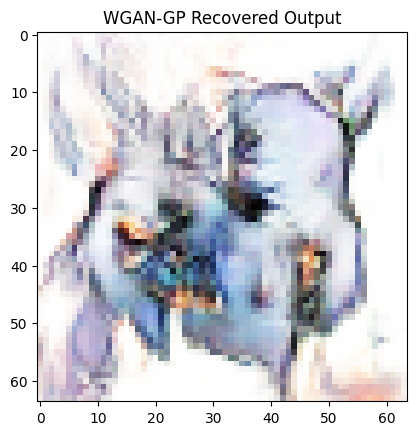

In [8]:
import matplotlib.pyplot as plt

# Test generation
gen_wgan.eval()
noise = torch.randn(1, 100, 1, 1).to(device)
with torch.no_grad():
    sample = gen_wgan(noise).cpu().squeeze().permute(1, 2, 0).numpy()
    # Normalize to [0, 1] for plotting
    sample = (sample + 1) / 2

plt.imshow(sample)
plt.title("WGAN-GP Recovered Output")
plt.show()

## 2. Configuration

In [9]:
IMAGE_SIZE = 64
CHANNELS = 3
Z_DIM = 100
BATCH_SIZE = 64
LR = 2e-4
BETAS = (0.5, 0.999)

EPOCHS_DCGAN = 50          
EPOCHS_WGANGP = 60
SAVE_EVERY = 5

LAMBDA_GP = 10.0
N_CRITIC = 5

NGF = 64
NDF = 64

MAX_TRAIN_IMAGES = None
MONITOR_GPU_MEMORY = True
FORCE_RETRAIN_DCGAN = True
DCGAN_USE_AMP = False

KAGGLE_INPUT_ROOT = Path('/kaggle/input')
WORK_ROOT = Path('/kaggle/working')
CHECKPOINT_DIR = WORK_ROOT / 'checkpoint'
SAMPLES_DIR = WORK_ROOT / 'samples'

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = True

print('Input root:', KAGGLE_INPUT_ROOT)
print('Checkpoint dir:', CHECKPOINT_DIR)
print('Samples dir:', SAMPLES_DIR)
print('Num workers:', NUM_WORKERS)
print('Max train images:', MAX_TRAIN_IMAGES if MAX_TRAIN_IMAGES is not None else 'All')
print('Monitor GPU memory:', MONITOR_GPU_MEMORY)
print('Force retrain DCGAN:', FORCE_RETRAIN_DCGAN)
print('DCGAN mixed precision (AMP):', DCGAN_USE_AMP)

Input root: /kaggle/input
Checkpoint dir: /kaggle/working/checkpoint
Samples dir: /kaggle/working/samples
Num workers: 4
Max train images: All
Monitor GPU memory: True
Force retrain DCGAN: True
DCGAN mixed precision (AMP): False


## 3. Dataset and DataLoader

In [10]:
class ImagePathDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        with Image.open(self.image_paths[idx]) as img:
            # Handle paletted PNGs with transparency safely before RGB conversion.
            if img.mode == 'P' and 'transparency' in img.info:
                img = img.convert('RGBA')
            image = img.convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image

def get_target_dataset_dirs(root: Path):
    if not root.exists():
        return []

    # Search mounted Kaggle dataset directories up to a few levels deep.
    candidate_dirs = []
    depth_patterns = ['*', '*/*', '*/*/*']
    for pattern in depth_patterns:
        candidate_dirs.extend([p for p in root.glob(pattern) if p.is_dir()])

    hint_keys = ('anime', 'pokemon', 'sprite', 'face', 'faces')
    target_dirs = [d for d in candidate_dirs if any(k in d.name.lower() for k in hint_keys)]

    # If explicit name match is missing, fallback to directories that look like image folders.
    if len(target_dirs) == 0:
        exts = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}
        for d in candidate_dirs:
            try:
                sample_files = list(d.iterdir())[:50]
            except Exception:
                continue
            img_count = sum(1 for f in sample_files if f.is_file() and f.suffix.lower() in exts)
            if img_count >= 5:
                target_dirs.append(d)

    # Remove duplicates while preserving order.
    seen = set()
    deduped = []
    for d in target_dirs:
        s = str(d)
        if s not in seen:
            deduped.append(d)
            seen.add(s)
    return deduped

def collect_images_from_dirs(dataset_dirs):
    exts = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}
    image_paths = []
    for ds_dir in dataset_dirs:
        for ext in exts:
            image_paths.extend(ds_dir.rglob(f'*{ext}'))
    return sorted(str(p) for p in image_paths if p.is_file())

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

dataset_dirs = get_target_dataset_dirs(KAGGLE_INPUT_ROOT)
if len(dataset_dirs) == 0:
    available = [p.name for p in KAGGLE_INPUT_ROOT.iterdir()] if KAGGLE_INPUT_ROOT.exists() else []
    raise RuntimeError(f'Anime/Pokemon dataset folder not found under /kaggle/input. Available top-level dirs: {available}')

print('Using dataset folders:')
for d in dataset_dirs[:10]:
    print(' -', d)
if len(dataset_dirs) > 10:
    print(f'... and {len(dataset_dirs)-10} more')

image_paths = collect_images_from_dirs(dataset_dirs)
if len(image_paths) == 0:
    raise RuntimeError('No images found inside selected dataset folders.')

if MAX_TRAIN_IMAGES is not None and MAX_TRAIN_IMAGES > 0:
    image_paths = image_paths[:int(MAX_TRAIN_IMAGES)]
    print(f'Using subset of images: {len(image_paths)}')

print(f'Found {len(image_paths)} images.')
dataset = ImagePathDataset(image_paths, transform=transform)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

def _seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=True,
    worker_init_fn=_seed_worker,
    generator=loader_generator
)

print('Total images:', len(dataset))
print('Batches/epoch:', len(dataloader))
print('Example image path:', image_paths[0])

Using dataset folders:
 - /kaggle/input/datasets/jackemartin/pokemon-sprites
 - /kaggle/input/datasets/soumikrakshit/anime-faces
Found 76989 images.
Total images: 76989
Batches/epoch: 1202
Example image path: /kaggle/input/datasets/jackemartin/pokemon-sprites/pokemon_images/pokemondb.net/abomasnow0.jpg


## 4. Utility Functions

In [11]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if getattr(m, 'bias', None) is not None:
            nn.init.constant_(m.bias.data, 0)
    elif classname.find('BatchNorm') != -1 or classname.find('InstanceNorm') != -1:
        if getattr(m, 'weight', None) is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if getattr(m, 'bias', None) is not None:
            nn.init.constant_(m.bias.data, 0)

def get_latest_epoch(prefix):
    pattern = str(CHECKPOINT_DIR / f'{prefix}_epoch_*.pt')
    ckpts = glob.glob(pattern)
    if len(ckpts) == 0:
        return 0

    def _epoch(path):
        m = re.search(rf'{re.escape(prefix)}_epoch_(\d+)\.pt$', os.path.basename(path))
        return int(m.group(1)) if m else -1

    return max(max(_epoch(p) for p in ckpts), 0)

def save_checkpoint(prefix, epoch, model_g, model_d_or_c, opt_g, opt_d_or_c, scaler_g, scaler_d_or_c):
    ckpt_path = CHECKPOINT_DIR / f'{prefix}_epoch_{epoch:02d}.pt'
    torch.save({
        'epoch': int(epoch),
        'model_g': model_g.state_dict(),
        'model_d_or_c': model_d_or_c.state_dict(),
        'opt_g': opt_g.state_dict(),
        'opt_d_or_c': opt_d_or_c.state_dict(),
        'scaler_g': scaler_g.state_dict() if scaler_g is not None else None,
        'scaler_d_or_c': scaler_d_or_c.state_dict() if scaler_d_or_c is not None else None
    }, ckpt_path)

def load_latest_checkpoint(prefix, model_g, model_d_or_c, opt_g, opt_d_or_c, scaler_g=None, scaler_d_or_c=None):
    latest_epoch = get_latest_epoch(prefix)
    if latest_epoch == 0:
        return 0

    latest_path = CHECKPOINT_DIR / f'{prefix}_epoch_{latest_epoch:02d}.pt'
    state = torch.load(latest_path, map_location=device)

    model_g.load_state_dict(state['model_g'])
    model_d_or_c.load_state_dict(state['model_d_or_c'])
    opt_g.load_state_dict(state['opt_g'])
    opt_d_or_c.load_state_dict(state['opt_d_or_c'])

    if scaler_g is not None and state.get('scaler_g') is not None:
        scaler_g.load_state_dict(state['scaler_g'])
    if scaler_d_or_c is not None and state.get('scaler_d_or_c') is not None:
        scaler_d_or_c.load_state_dict(state['scaler_d_or_c'])

    print(f"Resumed {prefix} from epoch {state['epoch']}: {latest_path}")
    return int(state['epoch'])

def generate_fixed_noise(n=64, z_dim=100, device=device):
    return torch.randn(n, z_dim, 1, 1, device=device)

@torch.no_grad()
def save_generated_images_grid(generator, fixed_noise, epoch, prefix, nrow=8):
    generator.eval()
    fake = generator(fixed_noise).detach().cpu()
    grid = make_grid(fake, nrow=nrow, normalize=True, value_range=(-1, 1))
    out_path = SAMPLES_DIR / f'{prefix}_epoch_{epoch:02d}.png'
    save_image(grid, out_path)
    generator.train()

print('Utility functions loaded: weights_init, checkpointing, fixed noise, and sample grid saver.')

Utility functions loaded: weights_init, checkpointing, fixed noise, and sample grid saver.


## 5. DCGAN Generator

In [12]:
class DCGANGenerator(nn.Module):
    def __init__(self, z_dim=100, channels_img=3, features_g=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, features_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g, channels_img, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

print('DCGAN Generator class loaded.')

DCGAN Generator class loaded.


## 6. DCGAN Discriminator

In [13]:
class DCGANDiscriminator(nn.Module):
    """DCGAN-style D: no BatchNorm on first conv; raw logits (BCEWithLogitsLoss)."""
    def __init__(self, channels_img=3, features_d=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels_img, features_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),          # inplace=True — proper gradient flow
            nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(features_d * 8, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)

print('DCGAN Discriminator loaded.')

DCGAN Discriminator loaded.


## 7. DCGAN Training Loop

In [14]:
def train_dcgan(dataloader, epochs=50):
    gen = DCGANGenerator(z_dim=Z_DIM, channels_img=CHANNELS, features_g=NGF).to(device)
    disc = DCGANDiscriminator(channels_img=CHANNELS, features_d=NDF).to(device)
    gen.apply(weights_init)
    disc.apply(weights_init)

    criterion = nn.BCEWithLogitsLoss()

    # G: 2e-4, D: 8e-5 — D thoda slow taake G seekh sake
    opt_g = optim.Adam(gen.parameters(), lr=2e-4, betas=BETAS)
    opt_d = optim.Adam(disc.parameters(), lr=8e-5, betas=BETAS)

    dcgan_amp = amp_enabled and DCGAN_USE_AMP
    scaler_device_str = 'cuda' if dcgan_amp else 'cpu'
    scaler_g = torch.amp.GradScaler(scaler_device_str, enabled=dcgan_amp)
    scaler_d = torch.amp.GradScaler(scaler_device_str, enabled=dcgan_amp)
    fixed_noise = generate_fixed_noise(n=64, z_dim=Z_DIM, device=device)

    history = {'epoch': [], 'loss_d': [], 'loss_g': []}

    if FORCE_RETRAIN_DCGAN:
        print('FORCE_RETRAIN_DCGAN=True -> starting from scratch.')
        start_epoch = 0
    else:
        start_epoch = load_latest_checkpoint('dcgan', gen, disc, opt_g, opt_d, scaler_g, scaler_d)
        if start_epoch >= epochs:
            print(f'DCGAN already trained up to epoch {start_epoch}.')
            return gen, disc, history

    for epoch in range(start_epoch + 1, epochs + 1):
        running_loss_d = 0.0
        running_loss_g = 0.0
        pbar = tqdm(dataloader, desc=f'DCGAN Epoch {epoch}/{epochs}', leave=False)

        for real in pbar:
            real = real.to(device, non_blocking=True)
            b_size = real.size(0)

            # One-sided label smoothing — sirf real labels pe
            real_labels = torch.empty(b_size, device=device).uniform_(0.85, 0.95)
            fake_labels = torch.zeros(b_size, device=device)    # fake strict 0
            gen_target  = torch.ones(b_size, device=device)     # G full 1.0 target

            # ════ Train Discriminator — 1 step only ════
            opt_d.zero_grad(set_to_none=True)
            noise = torch.randn(b_size, Z_DIM, 1, 1, device=device)

            with torch.amp.autocast(device_type=device.type, enabled=dcgan_amp):
                fake      = gen(noise).detach()   # detach — G update nahi hoga yahan
                out_real  = disc(real)
                out_fake  = disc(fake)
                loss_d    = 0.5 * (criterion(out_real, real_labels) +
                                   criterion(out_fake, fake_labels))

            scaler_d.scale(loss_d).backward()
            scaler_d.unscale_(opt_d)
            nn.utils.clip_grad_norm_(disc.parameters(), max_norm=10.0)
            scaler_d.step(opt_d)
            scaler_d.update()

            # ════ Train Generator — 1 step only ════
            opt_g.zero_grad(set_to_none=True)
            noise2 = torch.randn(b_size, Z_DIM, 1, 1, device=device)

            with torch.amp.autocast(device_type=device.type, enabled=dcgan_amp):
                fake2     = gen(noise2)
                out_fake2 = disc(fake2)
                loss_g    = criterion(out_fake2, gen_target)

            scaler_g.scale(loss_g).backward()
            scaler_g.unscale_(opt_g)
            nn.utils.clip_grad_norm_(gen.parameters(), max_norm=10.0)
            scaler_g.step(opt_g)
            scaler_g.update()

            running_loss_d += float(loss_d.item())
            running_loss_g += float(loss_g.item())
            pbar.set_postfix(loss_d=f'{loss_d.item():.4f}',
                             loss_g=f'{loss_g.item():.4f}')

        epoch_loss_d = running_loss_d / len(dataloader)
        epoch_loss_g = running_loss_g / len(dataloader)
        history['epoch'].append(epoch)
        history['loss_d'].append(epoch_loss_d)
        history['loss_g'].append(epoch_loss_g)

        print(f'DCGAN Epoch {epoch}/{epochs} | '
              f'Loss_D: {epoch_loss_d:.4f} | Loss_G: {epoch_loss_g:.4f}')

        if device.type == 'cuda' and MONITOR_GPU_MEMORY:
            alloc    = torch.cuda.memory_allocated() / (1024 ** 3)
            reserved = torch.cuda.memory_reserved()  / (1024 ** 3)
            print(f'GPU Memory | Allocated: {alloc:.2f} GB | Reserved: {reserved:.2f} GB')

        # Har epoch images save — output folder kabhi khali nahi rahega
        save_generated_images_grid(gen, fixed_noise, epoch, prefix='dcgan')

        # Checkpoint har SAVE_EVERY epochs pe
        if epoch % SAVE_EVERY == 0:
            save_checkpoint('dcgan', epoch, gen, disc, opt_g, opt_d, scaler_g, scaler_d)

        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return gen, disc, history

print('DCGAN training function loaded.')
gen_dcgan, disc_dcgan, dcgan_history = train_dcgan(dataloader, epochs=EPOCHS_DCGAN)

DCGAN training function loaded.
FORCE_RETRAIN_DCGAN=True -> starting from scratch.


DCGAN Epoch 1/50:   0%|          | 0/1202 [00:00<?, ?it/s]

DCGAN Epoch 1/50 | Loss_D: 0.5320 | Loss_G: 3.2366
GPU Memory | Allocated: 0.25 GB | Reserved: 0.44 GB


DCGAN Epoch 2/50:   0%|          | 0/1202 [00:00<?, ?it/s]

DCGAN Epoch 2/50 | Loss_D: 0.6052 | Loss_G: 1.5946
GPU Memory | Allocated: 0.25 GB | Reserved: 0.43 GB


...

DCGAN Epoch 34/50 | Loss_D: 0.2434 | Loss_G: 4.4955
GPU Memory | Allocated: 0.25 GB | Reserved: 0.45 GB


DCGAN Epoch 35/50:   0%|          | 0/1202 [00:00<?, ?it/s]

DCGAN Epoch 35/50 | Loss_D: 0.2334 | Loss_G: 4.5250
GPU Memory | Allocated: 0.25 GB | Reserved: 0.45 GB


DCGAN Epoch 36/50:   0%|          | 0/1202 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [22]:
import shutil
import os

# Source aur Destination paths
source = '/kaggle/working/checkpoint/dcgan_epoch_35.pt'
destination = '/kaggle/working/dcgan_35.pt'

if os.path.exists(source):
    shutil.copy(source, destination)
    print("✅ File successfully moved to main directory!")
else:
    print("❌ File source par nahi mili. Sidebar refresh karein.")

✅ File successfully moved to main directory!


## 8. WGAN-GP Generator

In [24]:
class WGANGPGenerator(nn.Module):
    def __init__(self, z_dim=100, channels_img=3, features_g=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, features_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g, channels_img, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

print('WGAN-GP Generator class loaded.')

WGAN-GP Generator class loaded.


## 9. WGAN-GP Critic

In [25]:
class WGANGPCritic(nn.Module):
    def __init__(self, channels_img=3, features_d=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels_img, features_d, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features_d, features_d * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(features_d * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(features_d * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(features_d * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features_d * 8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1)

print('WGAN-GP Critic class loaded.')

WGAN-GP Critic class loaded.


## 10. Gradient Penalty

In [26]:
def gradient_penalty(critic, real, fake, device):
    b_size = real.size(0)
    alpha = torch.rand(b_size, 1, 1, 1, device=device)
    interpolated = alpha * real + (1 - alpha) * fake
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)
    grad_outputs = torch.ones_like(mixed_scores, device=device)

    gradients = torch.autograd.grad(
        outputs=mixed_scores,
        inputs=interpolated,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(b_size, -1)
    return ((gradients.norm(2, dim=1) - 1.0) ** 2).mean()

print('Gradient penalty function loaded.')

Gradient penalty function loaded.


## 11. WGAN-GP Training Loop

In [ ]:
def train_wgangp(dataloader, epochs=60):
    gen = WGANGPGenerator(z_dim=Z_DIM, channels_img=CHANNELS, features_g=NGF).to(device)
    critic = WGANGPCritic(channels_img=CHANNELS, features_d=NDF).to(device)
    gen.apply(weights_init)
    critic.apply(weights_init)

    opt_g = optim.Adam(gen.parameters(), lr=LR, betas=BETAS)
    opt_c = optim.Adam(critic.parameters(), lr=LR, betas=BETAS)

    scaler_device = 'cuda' if amp_enabled else 'cpu'
    scaler_g = torch.amp.GradScaler(scaler_device, enabled=amp_enabled)
    scaler_c = torch.amp.GradScaler(scaler_device, enabled=amp_enabled)
    fixed_noise = generate_fixed_noise(n=64, z_dim=Z_DIM, device=device)

    history = {'epoch': [], 'loss_c': [], 'loss_g': []}

    start_epoch = load_latest_checkpoint('wgangp', gen, critic, opt_g, opt_c, scaler_g, scaler_c)
    if start_epoch >= epochs:
        print(f'WGAN-GP already trained up to epoch {start_epoch}.')
        return gen, critic, history

    global_step = start_epoch * len(dataloader)
    for epoch in range(start_epoch + 1, epochs + 1):
        running_loss_c = 0.0
        running_loss_g = 0.0
        pbar = tqdm(dataloader, desc=f'WGAN-GP Epoch {epoch}/{epochs}', leave=False)

        for real in pbar:
            real = real.to(device, non_blocking=True)
            b_size = real.size(0)
            noise = torch.randn(b_size, Z_DIM, 1, 1, device=device)

            opt_c.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                fake = gen(noise)
                critic_real = critic(real)
                critic_fake = critic(fake.detach())
                wasserstein_loss = critic_fake.mean() - critic_real.mean()

            gp = gradient_penalty(critic, real.float(), fake.detach().float(), device)
            loss_c = wasserstein_loss + LAMBDA_GP * gp

            scaler_c.scale(loss_c).backward()
            scaler_c.step(opt_c)
            scaler_c.update()

            loss_g_val = torch.tensor(0.0, device=device)
            if (global_step + 1) % N_CRITIC == 0:
                opt_g.zero_grad(set_to_none=True)
                noise2 = torch.randn(b_size, Z_DIM, 1, 1, device=device)

                with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                    fake2 = gen(noise2)
                    loss_g = -critic(fake2).mean()

                scaler_g.scale(loss_g).backward()
                scaler_g.step(opt_g)
                scaler_g.update()
                loss_g_val = loss_g.detach()

            running_loss_c += float(loss_c.item())
            running_loss_g += float(loss_g_val.item())
            pbar.set_postfix(loss_c=float(loss_c.item()), loss_g=float(loss_g_val.item()))
            global_step += 1

        epoch_loss_c = running_loss_c / len(dataloader)
        epoch_loss_g = running_loss_g / len(dataloader)
        history['epoch'].append(epoch)
        history['loss_c'].append(epoch_loss_c)
        history['loss_g'].append(epoch_loss_g)

        print(f'WGAN-GP Epoch {epoch}/{epochs} | Loss_C: {epoch_loss_c:.4f} | Loss_G: {epoch_loss_g:.4f}')
        if device.type == 'cuda' and MONITOR_GPU_MEMORY:
            alloc = torch.cuda.memory_allocated() / (1024 ** 3)
            reserved = torch.cuda.memory_reserved() / (1024 ** 3)
            print(f'GPU Memory | Allocated: {alloc:.2f} GB | Reserved: {reserved:.2f} GB')

        if epoch % SAVE_EVERY == 0:
            save_checkpoint('wgangp', epoch, gen, critic, opt_g, opt_c, scaler_g, scaler_c)
            save_generated_images_grid(gen, fixed_noise, epoch, prefix='wgangp')

        if device.type == 'cuda':
            torch.cuda.empty_cache()

    return gen, critic, history

print('WGAN-GP training function loaded.')
gen_wgan, critic_wgan, wgangp_history = train_wgangp(dataloader, epochs=EPOCHS_WGANGP)

In [ ]:
from pathlib import Path
import shutil
from IPython.display import display, HTML

src = Path("/kaggle/working/checkpoint/wgangp_epoch_60.pt")
dst = Path("/kaggle/working/wgangp_latest.pt")
shutil.copy2(src, dst)

print("File ready:", dst, f"{dst.stat().st_size/1024/1024:.2f} MB")

# Fresh links for current session
display(HTML("<a href='/files/wgangp_latest.pt?download=1' target='_blank'>Download wgangp_latest.pt</a>"))
display(HTML("<a href='/kaggle/working/wgangp_latest.pt' target='_blank'>Open file path</a>"))

## 12. Evaluation and Visualization

✅ DCGAN Loaded Successfully!


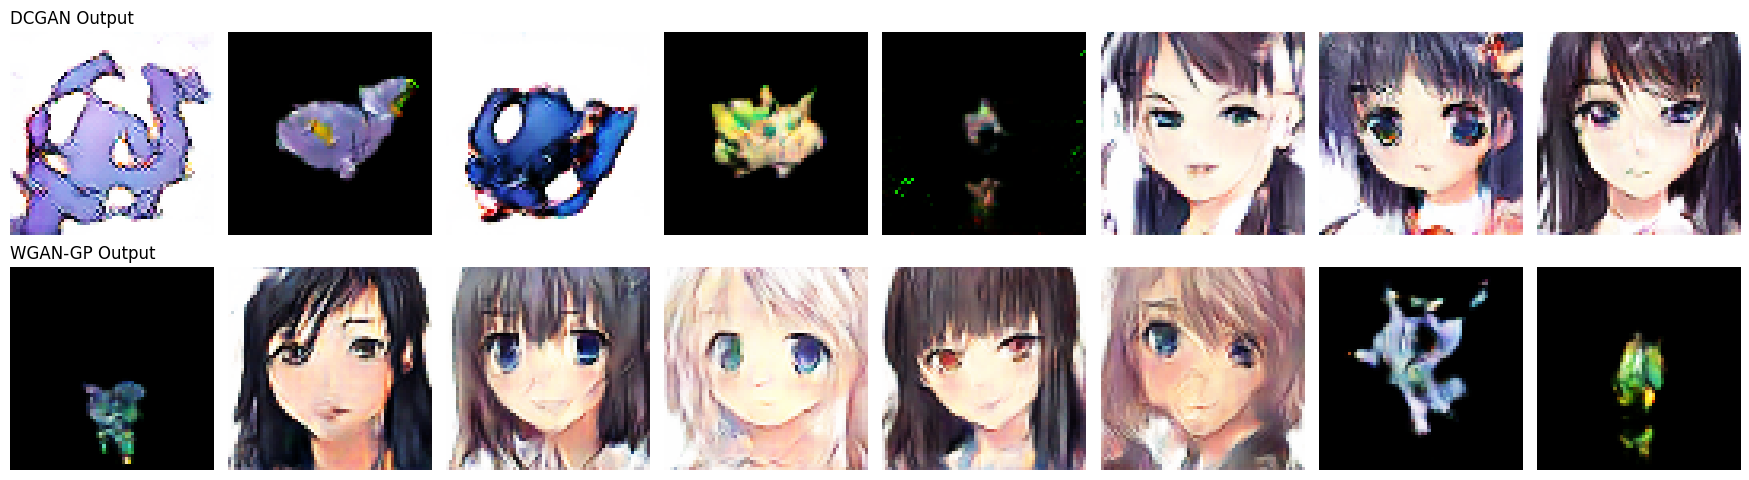

In [30]:
import torch
import torch.nn as nn
import os
import matplotlib.pyplot as plt

# 1. DCGAN Architecture (NAME FIXED: 'gen' changed to 'net')
class DCGANGenerator(nn.Module):
    def __init__(self, z_dim=100, channels_img=3, features_g=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, features_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g, channels_img, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
    def forward(self, x): return self.net(x)

# 2. Setup & Loading
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Z_DIM = 100
gen_dcgan = DCGANGenerator(z_dim=Z_DIM).to(device)

dcgan_path = '/kaggle/working/checkpoint/dcgan_epoch_35.pt'

if os.path.exists(dcgan_path):
    checkpoint = torch.load(dcgan_path, map_location=device)
    
    # Checkpoint handle karein
    state_dict = checkpoint['model_g'] if isinstance(checkpoint, dict) and 'model_g' in checkpoint else checkpoint
    
    # Load weights
    gen_dcgan.load_state_dict(state_dict)
    print(f"✅ DCGAN Loaded Successfully!")

# 3. Sample & Visualize
@torch.no_grad()
def sample_images(generator, n=8):
    generator.eval()
    noise = torch.randn(n, Z_DIM, 1, 1, device=device)
    imgs = generator(noise).detach().cpu()
    return imgs

n_samples = 8
dcgan_imgs = sample_images(gen_dcgan, n=n_samples)

# Ensure gen_wgan is also loaded from previous steps
try:
    wgan_imgs = sample_images(gen_wgan, n=n_samples)
    
    fig, axes = plt.subplots(2, n_samples, figsize=(2.2 * n_samples, 5))
    for i in range(n_samples):
        # DCGAN Row
        img_d = (dcgan_imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        axes[0, i].imshow(img_d)
        axes[0, i].axis('off')

        # WGAN Row
        img_w = (wgan_imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        axes[1, i].imshow(img_w)
        axes[1, i].axis('off')

    axes[0, 0].set_title('DCGAN Output', fontsize=12, loc='left')
    axes[1, 0].set_title('WGAN-GP Output', fontsize=12, loc='left')
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("❌ gen_wgan load nahi hua. Pehle WGAN load wala cell run karein.")

## 13. Training Curves and Artifacts

--- Final Artifact Summary ---
 ✅ DCGAN Sample Grids: 35 found
 ✅ WGAN-GP Sample Grids: 1 found


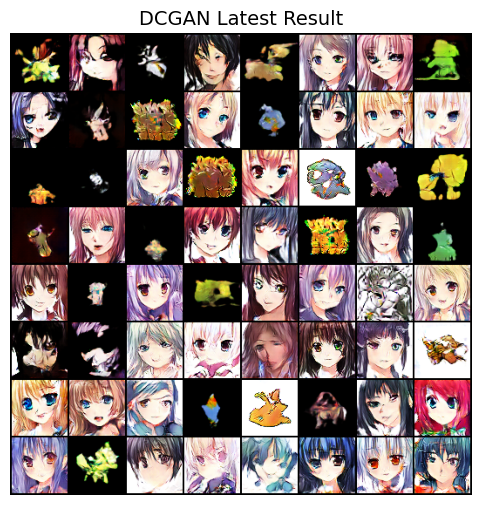

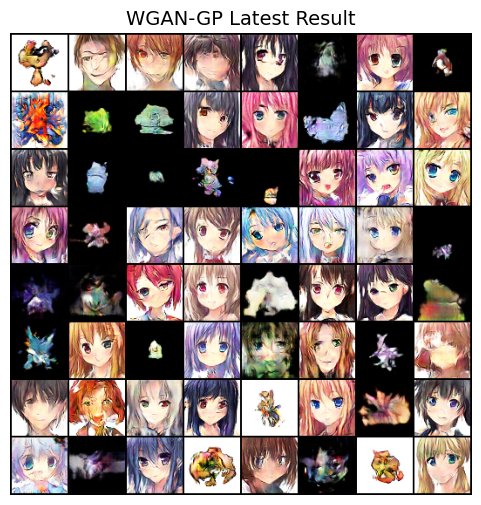


--- Diversity Analysis ---
 ⭐ DCGAN Diversity Score: 112.1351
 ⭐ WGAN-GP Diversity Score: 107.2237


In [42]:
import torch
import glob
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import os

# 1. Paths scan karein (Working aur Input dono check karenge)
WORKING_DIR = Path('/kaggle/working')
# WGAN samples aksar input dataset mein hotay hain
INPUT_DIR = Path('/kaggle/input') 

def _safe_glob_sorted(pattern):
    files = glob.glob(str(pattern), recursive=True)
    return sorted(files)

# DCGAN samples (Working directory)
dc_samples = _safe_glob_sorted(WORKING_DIR / '**/dcgan_epoch_*.jpg') + \
             _safe_glob_sorted(WORKING_DIR / '**/dcgan_epoch_*.png')

# WGAN-GP samples (Input directory mein dhoondein)
wg_samples = _safe_glob_sorted(INPUT_DIR / '**/wgangp_epoch_*.jpg') + \
             _safe_glob_sorted(INPUT_DIR / '**/wgangp_epoch_*.png') + \
             _safe_glob_sorted(WORKING_DIR / '**/wgangp_epoch_*.png')

print('--- Final Artifact Summary ---')
print(f' ✅ DCGAN Sample Grids: {len(dc_samples)} found')
print(f' ✅ WGAN-GP Sample Grids: {len(wg_samples)} found')

# --- Final Visualization ---
def _show_last_sample(sample_list, title):
    if len(sample_list) == 0:
        print(f'⚠️ No sample found for {title}. Path check karein.')
        return
    
    last_file = sample_list[-1]
    img = Image.open(last_file).convert('RGB')
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f'{title} Latest Result', fontsize=14)
    plt.axis('off')
    plt.show()

_show_last_sample(dc_samples, 'DCGAN')
_show_last_sample(wg_samples, 'WGAN-GP')

# --- Diversity Analysis (Safe Execution) ---
print('\n--- Diversity Analysis ---')
@torch.no_grad()
def get_score(gen_model):
    gen_model.eval()
    z = torch.randn(32, 100, 1, 1, device=next(gen_model.parameters()).device)
    imgs = gen_model(z).detach().cpu().view(32, -1)
    return torch.cdist(imgs, imgs, p=2).mean().item()

if 'gen_dcgan' in globals():
    print(f' ⭐ DCGAN Diversity Score: {get_score(gen_dcgan):.4f}')
if 'gen_wgan' in globals():
    print(f' ⭐ WGAN-GP Diversity Score: {get_score(gen_wgan):.4f}')

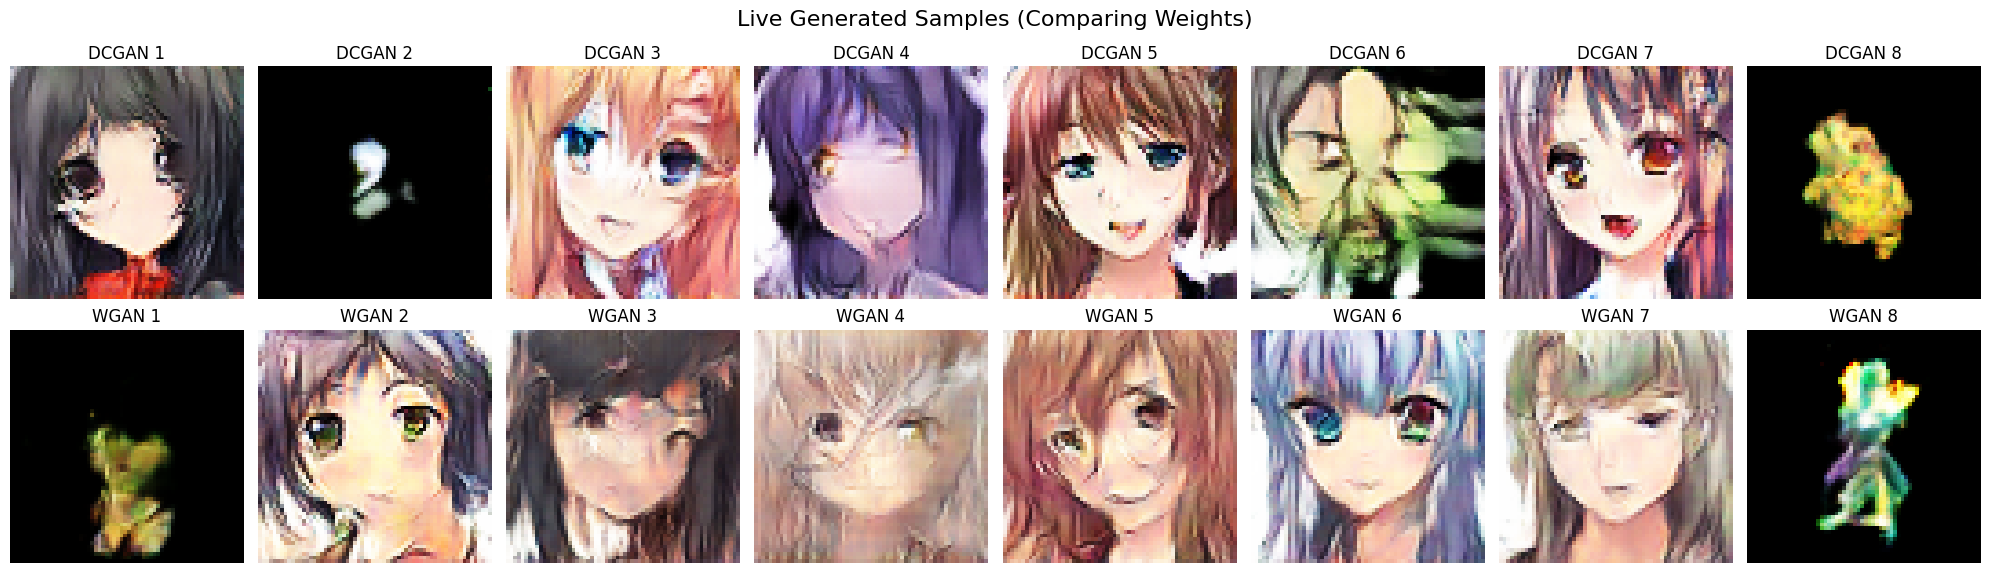

✅ Final comparison image saved as 'final_comparison_live.png'


<Figure size 640x480 with 0 Axes>

In [40]:
import torch
import matplotlib.pyplot as plt

# 1. Models ko evaluation mode mein karein
gen_dcgan.eval()
gen_wgan.eval()

# 2. Random noise generate karein (8 images ke liye)
Z_DIM = 100
device = next(gen_dcgan.parameters()).device
noise = torch.randn(8, Z_DIM, 1, 1).to(device)

# 3. Generate images
with torch.no_grad():
    dcgan_results = gen_dcgan(noise).detach().cpu()
    wgan_results = gen_wgan(noise).detach().cpu()

# 4. Plotting
fig, axes = plt.subplots(2, 8, figsize=(20, 6))

for i in range(8):
    # DCGAN Row
    img_d = (dcgan_results[i].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    axes[0, i].imshow(img_d)
    axes[0, i].set_title(f"DCGAN {i+1}")
    axes[0, i].axis('off')

    # WGAN Row
    img_w = (wgan_results[i].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    axes[1, i].imshow(img_w)
    axes[1, i].set_title(f"WGAN {i+1}")
    axes[1, i].axis('off')

plt.suptitle("Live Generated Samples (Comparing Weights)", fontsize=16)
plt.tight_layout()
plt.show()

# 5. Save this for your report
plt.savefig('final_comparison_live.png')
print("✅ Final comparison image saved as 'final_comparison_live.png'")

## 14. App Deployment (Gradio Demo)

In [43]:
try:
    import gradio as gr
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'gradio'])
    import gradio as gr

def _tensor_batch_to_pil_grid(batch_tensor):
    n = batch_tensor.size(0)
    nrow = max(1, int(np.sqrt(n)))
    grid = make_grid(batch_tensor.detach().cpu(), nrow=nrow, normalize=True, value_range=(-1, 1))
    grid_np = grid.permute(1, 2, 0).numpy()
    grid_np = (grid_np * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(grid_np)

def _pick_generator(model_name):
    if model_name == 'DCGAN':
        return globals().get('gen_dcgan', None)
    return globals().get('gen_wgan', None)

@torch.no_grad()
def gradio_generate(model_name, n_samples, seed):
    model = _pick_generator(model_name)
    if model is None:
        return None, f'{model_name} is not available. Run training cells first.'

    n_samples = int(max(1, min(64, n_samples)))
    seed = int(seed)
    g = torch.Generator(device=device)
    g.manual_seed(seed)

    model.eval()
    z = torch.randn(n_samples, Z_DIM, 1, 1, generator=g, device=device)
    with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
        fake = model(z)
    out_img = _tensor_batch_to_pil_grid(fake)
    model.train()

    msg = f'Generated {n_samples} samples using {model_name} (seed={seed}).'
    return out_img, msg

with gr.Blocks(title='GAN Image Generation Demo', theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        '# GAN Image Generation Demo\n'
        'Generate image grids from trained **DCGAN** and **WGAN-GP** models.'
    )

    with gr.Row():
        model_dd = gr.Dropdown(choices=['DCGAN', 'WGAN-GP'], value='WGAN-GP', label='Model')
        n_slider = gr.Slider(minimum=4, maximum=36, step=4, value=16, label='Number of Samples')
        seed_num = gr.Number(value=42, precision=0, label='Seed')

    run_btn = gr.Button('Generate', variant='primary')
    out_img = gr.Image(type='pil', label='Generated Grid')
    out_txt = gr.Textbox(label='Status', lines=2)

    run_btn.click(
        fn=gradio_generate,
        inputs=[model_dd, n_slider, seed_num],
        outputs=[out_img, out_txt]
    )

demo.launch(share=True, server_name='0.0.0.0', server_port=7860)

/tmp/ipykernel_55/1710690643.py:43: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='GAN Image Generation Demo', theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://0.0.0.0:7860
* Running on public URL: https://fe436d24b27fbb4b0e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
